# Week - 2 [Noisy Data]

### Data Mining - A

---------------------------------------------

### Pengantar Noisy Data

Dalam dunia data science dan machine learning, noisy data mengacu pada data yang mengandung kesalahan, inkonsistensi, atau informasi yang tidak relevan, yang dapat mengganggu analisis atau pemodelan. Noisy data bisa muncul dalam berbagai bentuk dan disebabkan oleh berbagai faktor, seperti kesalahan manusi atau gangguan dalam proses pengumpulan data.

Tidak ada klasifikasi baku untuk Noisy Data, tetapi kita bisa mengelompokkannya berdasarkan kasus yang sering muncul dalam praktik nyata. Dalam dataset ini, kita akan fokus pada tiga tipe utama Noisy Data yang sering ditemukan:

1. Inconsistent Data (Data Tidak Konsisten)
2. Misclassified Data (Data Salah Klasifikasi)
3. Improper Data Format (Format Data Tidak Tepat)
4. Outliers

sumber: https://www.geeksforgeeks.org/how-to-handle-noise-in-machine-learning/

![image.png](attachment:image.png)

-------------------------------------------------------

### Latihan

import dataset berikut ini.
https://www.kaggle.com/datasets/shashankshukla123123/linkedin-job-data

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("linkdin_Job_data.csv")
df.head()

,job_ID,job,location,company_id,company_name,work_type,full_time_remote,no_of_employ,no_of_application,posted_day_ago,alumni,Hiring_person,linkedin_followers,hiring_person_link,job_details,Column1
0,3471657636,"Data Analyst, Trilogy (Remote) - $60,000/year USD","Delhi, Delhi, India",NaN,Crossover,Remote,Full-time · Associate,"1,001-5,000 employees · IT Services and IT Con...",200,8 hours,12 company alumni,NaN,"5,395,547 followers",NaN,About the job Crossover is the world's #1 sour...,NaN
1,3471669068,"Data Analyst, Trilogy (Remote) - $60,000/year USD","New Delhi, Delhi, India",NaN,Crossover,Remote,Full-time · Associate,"1,001-5,000 employees · IT Services and IT Con...",184,8 hours,12 company alumni,NaN,"5,395,547 followers",NaN,About the job Crossover is the world's #1 sour...,NaN
2,3474349934,Data Analyst - WFH,Greater Bengaluru Area,NaN,Uplers,Remote,Full-time · Mid-Senior level,"1,001-5,000 employees · IT Services and IT Con...",200,9 hours,3 company alumni,Shahid Ahmad,NaN,https://www.linkedin.com/in/shahid-ahmad-a2613...,About the job Profile: ML EngineersExperience:...,NaN
3,3472816027,Data Analyst,"Gurugram, Haryana, India",NaN,PVAR SERVICES,On-site,Full-time,1-10 employees,200,7 hours,NaN,Vartika Singh,"2,094 followers",https://www.linkedin.com/in/vartika-singh-,About the job Designation: Data AnalystLocatio...,NaN
4,3473311511,Data Analyst,"Mohali district, Punjab, India",NaN,Timeline Freight Brokers,On-site,Full-time,1-10 employees,8,26 minutes,1 company alumni,Manisha (Gisele Smith),NaN,https://www.linkedin.com/in/manisharathore0029,About the job The ideal candidate will use the...,NaN


In [ ]:
summary_df = pd.DataFrame({
    "No.": range(1, len(df.columns) + 1),
    "Column Name": df.columns,
    "Data Type": df.dtypes.values,
    "Unique Values": [", ".join(map(str, df[col].dropna().unique()[:10])) for col in df.columns]
})
summary_df

,No.,Column Name,Data Type,Unique Values
0,1,job_ID,int64,"3471657636, 3471669068, 3474349934, 3472816027..."
1,2,job,object,"Data Analyst, Trilogy (Remote) - $60,000/year ..."
2,3,location,object,"Delhi, Delhi, India, New Delhi, Delhi, India, ..."
3,4,company_id,float64,
4,5,company_name,object,"Crossover, Uplers, PVAR SERVICES, Timeline Fre..."
5,6,work_type,object,"Remote, On-site, Hybrid"
6,7,full_time_remote,object,"Full-time · Associate, Full-time · Mid-Senior ..."
7,8,no_of_employ,object,"1,001-5,000 employees · IT Services and IT Con..."
8,9,no_of_application,object,"200, 184, 8, 2, 7, minutes, 22, 111, 36, 44"
9,10,posted_day_ago,object,"8 hours, 9 hours, 7 hours, 26 minutes, 10 hour..."


## 1. Inconsistent & Misclassified Data

##### 1. a) Bagaimana cara membersihkan kolom 'full_time_remote' agar hanya menyisakan kategori pekerjaan utama (Full-time, Contract, Part-time, Internship, Volunteer, Temporary) dan tetap mempertahankan nilai NaN?

In [ ]:
df['full_time_remote'].unique()

array(['Full-time · Associate', 'Full-time · Mid-Senior level',
       'Full-time', 'Full-time · Entry level', nan, 'Contract',
       'Contract · Associate', 'Contract · Mid-Senior level',
       'Full-time · Director', 'Internship', 'Contract · Entry level',
       'Full-time · Executive', 'Part-time',
       'Part-time · Mid-Senior level', 'Temporary',
       'Internship · Internship', '11-50 employees',
       'Full-time · Internship', 'Associate', '1-10 employees',
       'Internship · Entry level', 'Part-time · Associate', 'Volunteer',
       'Contract · Executive'], dtype=object)

In [ ]:
valid_categories = ["Full-time", "Contract", "Part-time", "Internship", "Volunteer", "Temporary"]

# Isi syntax lanjutan di bawah ini ...

##### 1. b) Bagaimana cara membersihkan data 'no_of_application' agar hanya berisi angka?

In [ ]:
df['no_of_application'].unique()

array(['200', '184', '8', '2', '7', 'minutes', '22', '111', '36', '44',
       '29', '4', '19', '14', '13', '32', '20', 'hours', '5', '21', '27',
       '85', '97', '42', '3', '1', '130', '127', '11', '16', '60', '17',
       '52', '50', '10', '61', '95', '39', '18', '6', '40', '138', '9',
       '26', '78', '47', '104', '15', '110', '25', '38', '122', '34',
       '149', '83', '57', '66', '56', '80', '135', '158', '139', '54',
       '28', '23', '12', '175', '35', '87', '109', '71', '70', '24', '96',
       '48', '103', '31', 'days', 'minute', '68', '147', 'day', '46',
       '65', nan, '59', '102', '53', '125', '143', '142', '150', '195',
       '160', '99', '112', '67', '74', '134', '43', '98', '146', '55',
       '108', '115', '176', '113', '30', '126', '76', '72', '129', '100',
       '172', 'hour', '51', 'seconds', '79', '163', '41', '86', '69',
       '132', '114', '136', '148', '77', '117', '164', '90', '33', '63',
       '73', '81', '106', '75', '45', '82', '156', '173', '37',

In [ ]:
# Isi syntax disini ...

##### 1. c) Data pada kolom 'posted_day_ago' saat ini memiliki berbagai satuan waktu (detik, menit, jam, hari, minggu), sehingga sulit untuk dibandingkan secara langsung. Agar bisa digunakan dalam analisis tren waktu, seperti melihat distribusi posting dalam beberapa jam terakhir, maka bagaimana cara mengubah kolom posted_day_ago menjadi format numerik dalam satuan menit?

In [ ]:
df['posted_day_ago'].unique()

array(['8 hours', '9 hours', '7 hours', '26 minutes', '10 hours',
       '25 minutes', '9 minutes', '5 hours', '20 hours', '6 hours',
       '1 hour', '2 hours', '12 hours', '22 hours', '4 hours', '3 hours',
       '1 day', '23 hours', '37 minutes', '11 hours', '14 hours',
       '18 hours', '19 hours', '6 minutes', '21 hours', '13 hours',
       '8 minutes', '15 hours', '10 minutes', '4 days', '5 days',
       '2 days', '6 days', '1 minute', '11 minutes', '50 minutes',
       '13 minutes', '16 hours', '17 hours', '3 days', '25 seconds',
       '17 minutes', '12 minutes', '47 minutes', '7 minutes',
       '58 minutes', '56 minutes', '27 minutes', '53 minutes',
       '45 minutes', '4 minutes', '57 minutes', '1 week', nan,
       '43 minutes', '32 minutes', '52 minutes', '39 minutes',
       '5 minutes', '14 minutes', '16 minutes', '15 minutes',
       '18 minutes', '19 minutes', '20 minutes', '23 minutes',
       '22 minutes', '21 minutes', '24 minutes', '28 minutes',
       '29 minute

In [ ]:
"""
def convert_to_minutes(value):
    if pd.isna(value):
        return np.nan

    Lanjutkan di bawah ...



df["posted_day_ago"] = df["posted_day_ago"].apply(convert_to_minutes)
"""

'\ndef convert_to_minutes(value):\n    if pd.isna(value):\n        return np.nan\n    \n    Lanjutkan di bawah ...\n    \n\n\ndf["posted_day_ago"] = df["posted_day_ago"].apply(convert_to_minutes)\n'

## 2. Konsep Binning

#### Binning adalah teknik dalam data preprocessing yang digunakan untuk mengelompokkan nilai numerik ke dalam beberapa kategori atau interval. Teknik ini membantu dalam reduksi kompleksitas data, mengurangi noise, serta memudahkan interpretasi dalam analisis dan visualisasi data.

##### Untuk mengetahui pola distribusi jumlah lamaran kerja (kolom 'no_of_application') dan bagaimana kompetisi antar lowongan di berbagai perusahaan, diperlukan binning untuk mengelompokkan jumlah lamaran ke dalam kategori tertentu.

##### Dengan binning, kita bisa melihat apakah suatu perusahaan lebih sering mendapatkan sedikit, sedang, atau banyak lamaran, yang dapat membantu dalam analisis daya tarik perusahaan bagi pencari kerja

In [ ]:
df_clean = df.dropna(subset=["no_of_application"])

<Axes: >

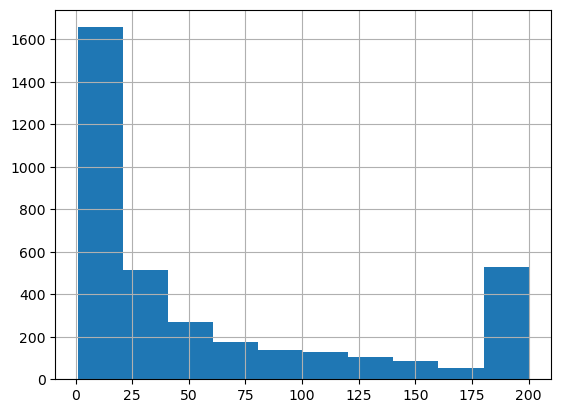

In [ ]:
df_clean['no_of_application'].hist(bins=10)

In [ ]:
df_clean["no_of_application_bins"] = pd.cut(df_clean["no_of_application"],
                                            bins=4, labels=["Sangat Sedikit", "Sedikit", "Banyak", "Sangat Banyak"])

C:\Users\Rasen\AppData\Local\Temp\ipykernel_24044\1712592236.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["no_of_application_bins"] = pd.cut(df_clean["no_of_application"],


<Axes: ylabel='count'>

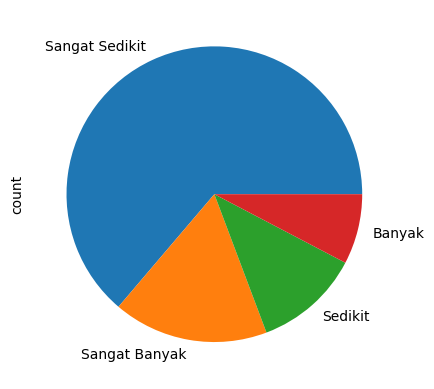

In [ ]:
df_clean["no_of_application_bins"].value_counts().plot.pie()